In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_excel(r'C:\Users\lenovo\Desktop\project 2\Dataset for Data Analytics.xlsx')
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [15]:
# Dataset Overview
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
df.info()


Shape: (1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   in

In [16]:
# Missing Values
df.isnull().sum()


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [17]:
# Descriptive Statistics
df.describe()


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [18]:
# Required Statistics
print('Mean TotalPrice =', df['TotalPrice'].mean())
print('Median TotalPrice =', df['TotalPrice'].median())
print('Count Orders =', df['OrderID'].count())


Mean TotalPrice = 1053.9683
Median TotalPrice = 823.615
Count Orders = 1200


## Product Analysis

In [19]:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
product_revenue


Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

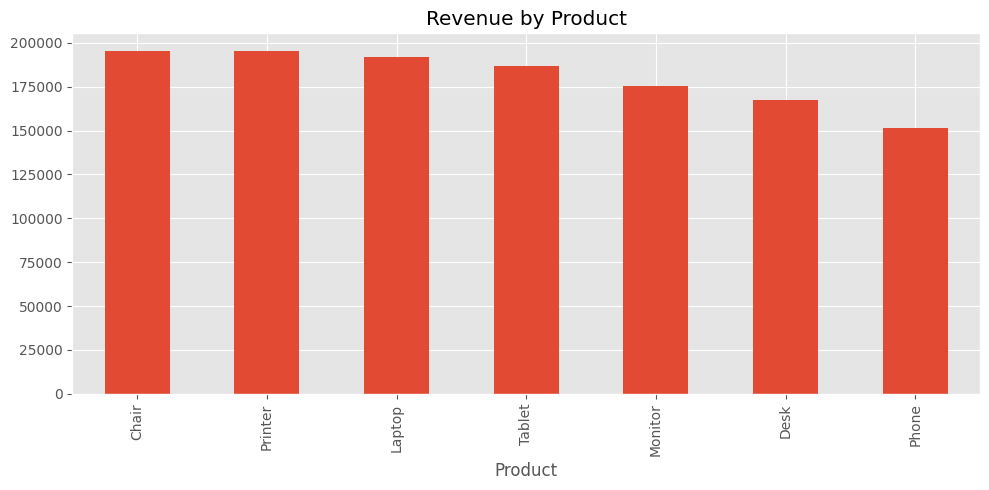

In [20]:
plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title('Revenue by Product')
plt.tight_layout()
plt.show()


## Order Status Analysis

In [21]:
df['OrderStatus'].value_counts()


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

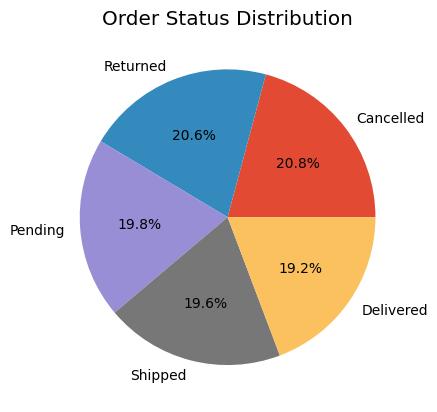

In [22]:
df['OrderStatus'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Order Status Distribution')
plt.show()


## Referral Source Analysis

In [23]:
ref = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
ref


ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

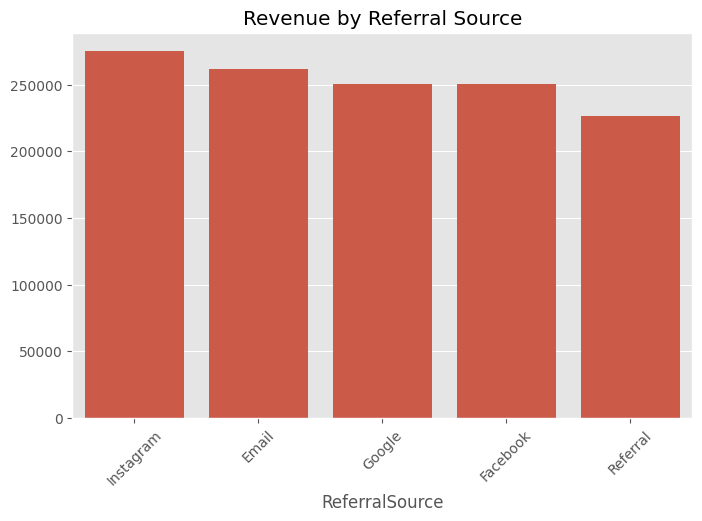

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x=ref.index, y=ref.values)
plt.xticks(rotation=45)
plt.title('Revenue by Referral Source')
plt.show()


## Distribution Analysis

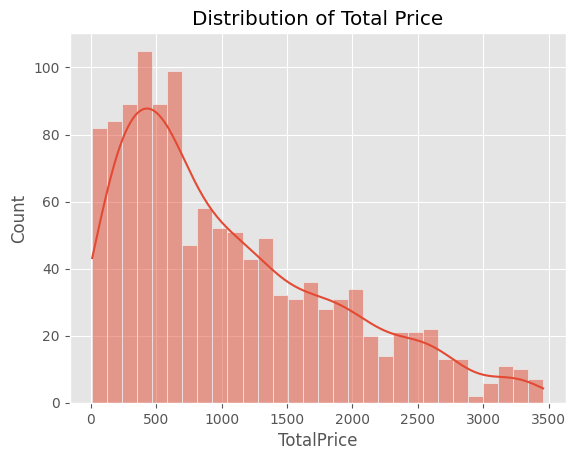

In [25]:
sns.histplot(df['TotalPrice'], bins=30, kde=True)
plt.title('Distribution of Total Price')
plt.show()


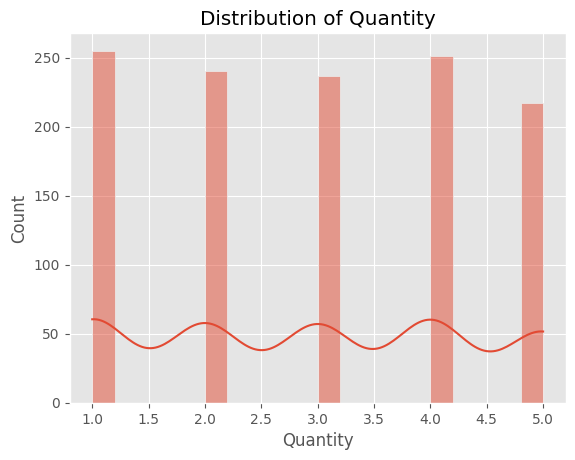

In [26]:
sns.histplot(df['Quantity'], bins=20, kde=True)
plt.title('Distribution of Quantity')
plt.show()


## Outlier Detection

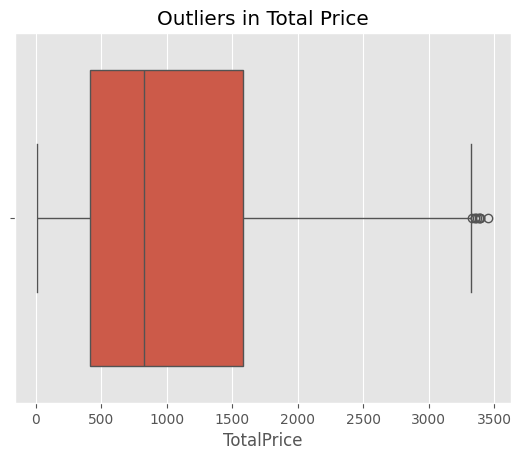

In [27]:
sns.boxplot(x=df['TotalPrice'])
plt.title('Outliers in Total Price')
plt.show()


## Correlation Analysis

In [28]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
corr


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


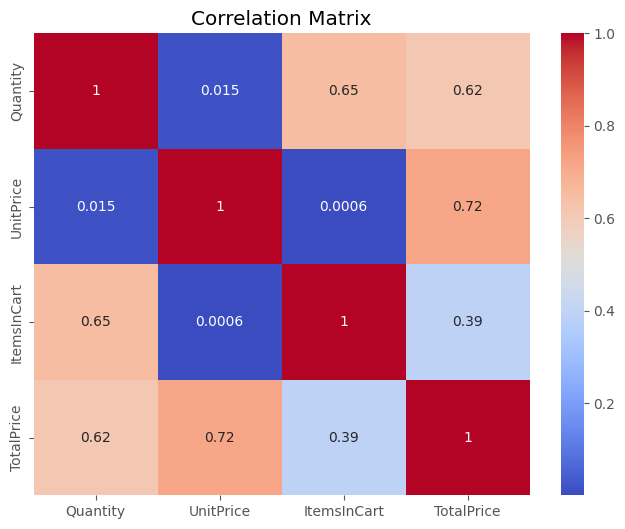

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


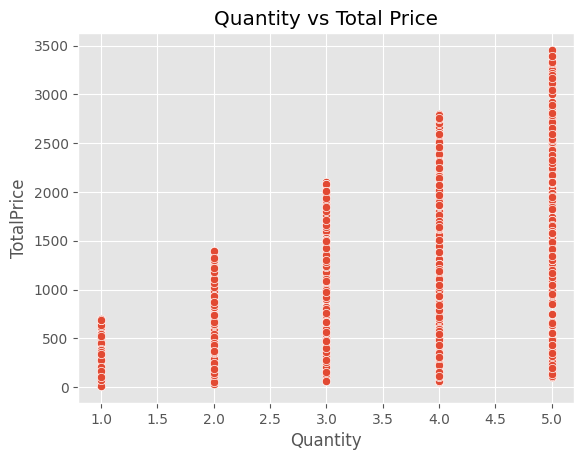

In [30]:
sns.scatterplot(data=df, x='Quantity', y='TotalPrice')
plt.title('Quantity vs Total Price')
plt.show()


In [ ]:
total_revenue = df["TotalPrice"].sum()

print("Total Revenue =", total_revenue)

In [ ]:
avg_order = df["TotalPrice"].mean()

print("Average Order Value =", round(avg_order,2))

In [ ]:
top_products = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print(top_products.head(10))

In [ ]:
df["PaymentMethod"].value_counts()

In [ ]:
sns.countplot(data=df, x="PaymentMethod")

plt.title("Payment Method Distribution")

plt.show()